<a href="https://colab.research.google.com/github/abdulmm44/Student_dropout_prediction/blob/main/Student_dropout_(37).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. **Problem Statement**
Higher education institutions face significant financial and reputational losses due to student dropout, yet they lack a systematic way to identify which students are likely to drop out before it happens.


## 1.1 Main Research Question

To what extent can academic and socioeconomic indicators predict student dropout risk, and which machine learning model provides the most accurate prediction of dropout among higher education students?

Sub-Questions

1. Which academic factors are most strongly associated with student dropout?

2. Which socioeconomic factors are most strongly associated with student dropout?

3. How do different machine learning algorithms perform in predicting student dropout

4. Which machine learning model achieves the highest predictive performance based on Accuracy, Precision, Recall, F1-Score, and ROC-AUC?

5. What are the most important features contributing to dropout prediction?









## 2. **Exploratory Data Analysis:** Data Loading,  Cleaning and Inspection


**Research Questions**
1. What characteristics distinguish dropouts from graduates?
2. Which features appear most predictive?
3. Are there highly correlated variables?
4. Are there potential issues for modeling?
5. What insights can be reported in the final paper?

In [3]:
# Importing the necessary libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif,
    RFE
)

# PCA
from sklearn.decomposition import PCA

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
#Reads the dataset from Github
df = pd.read_csv("https://raw.githubusercontent.com/abdulmm44/Student_dropout_prediction/refs/heads/main/data.csv", sep=';')

In [5]:
# understand the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [6]:
# First five row
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [7]:
df.shape

(4424, 37)

# Interpretation

We have:

- 4424 student records
- 36 predictor variables
- 1 target variable (Target)

In [8]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [9]:
# check for the missing data
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [10]:
# check for the duplicates
duplicates = df[df.duplicated()]

print(duplicates)

Empty DataFrame
Columns: [Marital status, Application mode, Application order, Course, Daytime/evening attendance	, Previous qualification, Previous qualification (grade), Nacionality, Mother's qualification, Father's qualification, Mother's occupation, Father's occupation, Admission grade, Displaced, Educational special needs, Debtor, Tuition fees up to date, Gender, Scholarship holder, Age at enrollment, International, Curricular units 1st sem (credited), Curricular units 1st sem (enrolled), Curricular units 1st sem (evaluations), Curricular units 1st sem (approved), Curricular units 1st sem (grade), Curricular units 1st sem (without evaluations), Curricular units 2nd sem (credited), Curricular units 2nd sem (enrolled), Curricular units 2nd sem (evaluations), Curricular units 2nd sem (approved), Curricular units 2nd sem (grade), Curricular units 2nd sem (without evaluations), Unemployment rate, Inflation rate, GDP, Target]
Index: []

[0 rows x 37 columns]


In [11]:
# dictionary mapping the old, messy names to new, clean names
# Format is {'Old Name': 'new_name'}
rename_mapping = {
    'Marital status': 'marital_status',
    'Application mode': 'app_mode',
    'Application order': 'app_order',
    'Daytime/evening attendance\t': 'daytime_attendance',
    'Previous qualification': 'prev_qual',
    'Previous qualification (grade)': 'prev_qual_grade',
    'Admission grade': 'admission_grade',
    'Nacionality': 'nationality',  # Fixing the spelling error
    "Mother's qualification": 'mother_qual',
    "Father's qualification": 'father_qual',
    "Mother's occupation": 'mother_occ',
    "Father's occupation": 'father_occ',
    'Educational special needs': 'special_needs',
    'Tuition fees up to date': 'tuition_current',
    'Scholarship holder': 'scholarship',
    'Age at enrollment': 'age',

    #  extremely long academic performance columns
    'Curricular units 1st sem (credited)': 'sem1_credited',
    'Curricular units 1st sem (enrolled)': 'sem1_enrolled',
    'Curricular units 1st sem (evaluations)': 'sem1_evals',
    'Curricular units 1st sem (approved)': 'sem1_approved',
    'Curricular units 1st sem (grade)': 'sem1_grade',
    'Curricular units 1st sem (without evaluations)': 'sem1_no_evals',

    'Curricular units 2nd sem (credited)': 'sem2_credited',
    'Curricular units 2nd sem (enrolled)': 'sem2_enrolled',
    'Curricular units 2nd sem (evaluations)': 'sem2_evals',
    'Curricular units 2nd sem (approved)': 'sem2_approved',
    'Curricular units 2nd sem (grade)': 'sem2_grade',
    'Curricular units 2nd sem (without evaluations)': 'sem2_no_evals',

    'Unemployment rate': 'unemployment_rate',
    'Inflation rate': 'inflation_rate',
    'GDP': 'gdp',
    'Target': 'target'
}

# Apply the renaming to both our machine dataset (df)
# inplace=True means it updates the dataframe directly without needing to reassign it
df.rename(columns=rename_mapping, inplace=True)

# Verify the changes
print(df.columns)

Index(['marital_status', 'app_mode', 'app_order', 'Course',
       'daytime_attendance', 'prev_qual', 'prev_qual_grade', 'nationality',
       'mother_qual', 'father_qual', 'mother_occ', 'father_occ',
       'admission_grade', 'Displaced', 'special_needs', 'Debtor',
       'tuition_current', 'Gender', 'scholarship', 'age', 'International',
       'sem1_credited', 'sem1_enrolled', 'sem1_evals', 'sem1_approved',
       'sem1_grade', 'sem1_no_evals', 'sem2_credited', 'sem2_enrolled',
       'sem2_evals', 'sem2_approved', 'sem2_grade', 'sem2_no_evals',
       'unemployment_rate', 'inflation_rate', 'gdp', 'target'],
      dtype='object')



Percentages:

target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64 




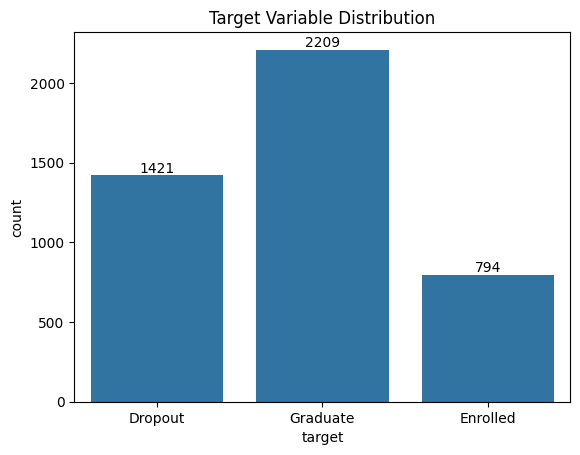

In [12]:
# Target variable analysis - Target Distribution
df['target'].value_counts()

print("\nPercentages:\n")
print(round(df["target"].value_counts(normalize=True)*100,2), "\n\n")

ax = sns.countplot(x='target',data=df)
plt.title('Target Variable Distribution')

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

In [13]:
df

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_credited,sem2_enrolled,sem2_evals,sem2_approved,sem2_grade,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [14]:
# Remove students with unresolved outcomes [Enrolled]

df_model = df[df["target"] != "Enrolled"].copy()

print(f"Original Shape: {df.shape}")
print(f"New Shape: {df_model.shape}")

Original Shape: (4424, 37)
New Shape: (3630, 37)


## **Justification of Removing `Enrolled`**

Students classified as `"Enrolled"` were removed from the analysis because their academic outcome remains unresolved. Retaining them would introduce uncertainty into the target variable and potentially bias the predictive models. Therefore, only students with definitive outcomes (`Graduate or Dropout`) were considered.

Target Counts:
target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Percentages:
target
Graduate    60.85
Dropout     39.15
Name: proportion, dtype: float64


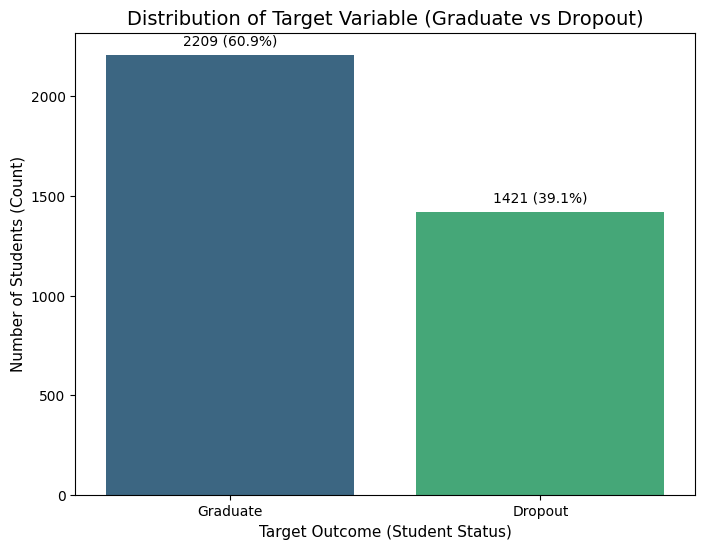

In [15]:
# Verifying Remaining Classes
target_counts = df_model["target"].value_counts()
target_percentages = round(df_model["target"].value_counts(normalize=True) * 100, 2)

print("Target Counts:")
print(target_counts)

print("\nPercentages:")
print(target_percentages)

# Plotting the distribution
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Target Variable (Graduate vs Dropout)', fontsize=14)
plt.xlabel('Target Outcome (Student Status)', fontsize=11)
plt.ylabel('Number of Students (Count)', fontsize=11)

# Add count and percentage labels on top of each bar
for i, p in enumerate(ax.patches):
    height = p.get_height()
    outcome_x = p.get_x() + p.get_width() / 2.
    count = int(height)
    # Get the category name using the index 'i'
    category_name = target_counts.index[i]
    percentage = target_percentages[category_name]
    ax.annotate(f'{count} ({percentage:.1f}%)', (outcome_x, height),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.show()

In [62]:
df_model

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_credited,sem2_enrolled,sem2_evals,sem2_approved,sem2_grade,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,0
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,1
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,1
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,0


In [16]:
# changing target variable into binary numerical
df_model['target'] = df_model['target'].replace({
    'Dropout': 1,
    'Graduate': 0
})

print(df_model['target'].value_counts())

print("\nUnique Values:")
print(df_model["target"].unique())


target
0    2209
1    1421
Name: count, dtype: int64

Unique Values:
[1 0]


In [67]:
df_model.T

,0,1,2,3,4,5,6,7,8,9,...,4414,4415,4416,4417,4418,4419,4420,4421,4422,4423
marital_status,1.00,1.000000,1.00,1.000000,2.000000,2.000000,1.000,1.00,1.000000,1.00,...,1.00,4.000000,1.000,1.000000,1.000000,1.000000,1.00,1.0000,1.00,1.000000
app_mode,17.00,15.000000,1.00,17.000000,39.000000,39.000000,1.000,18.00,1.000000,1.00,...,1.00,39.000000,43.000,1.000000,44.000000,1.000000,1.00,1.0000,1.00,10.000000
app_order,5.00,1.000000,5.00,2.000000,1.000000,1.000000,1.000,4.00,3.000000,1.00,...,1.00,1.000000,2.000,1.000000,1.000000,6.000000,2.00,1.0000,1.00,1.000000
Course,171.00,9254.000000,9070.00,9773.000000,8014.000000,9991.000000,9500.000,9254.00,9238.000000,9238.00,...,9130.00,9500.000000,9500.000,9070.000000,9070.000000,9773.000000,9773.00,9500.0000,9147.00,9773.000000
daytime_attendance,1.00,1.000000,1.00,1.000000,0.000000,0.000000,1.000,1.00,1.000000,1.00,...,1.00,1.000000,1.000,1.000000,1.000000,1.000000,1.00,1.0000,1.00,1.000000
prev_qual,1.00,1.000000,1.00,1.000000,1.000000,19.000000,1.000,1.00,1.000000,1.00,...,1.00,19.000000,1.000,1.000000,39.000000,1.000000,1.00,1.0000,1.00,1.000000
prev_qual_grade,122.00,160.000000,122.00,122.000000,100.000000,133.100000,142.000,119.00,137.000000,138.00,...,137.00,133.100000,136.000,132.000000,120.000000,125.000000,120.00,154.0000,180.00,152.000000
nationality,1.00,1.000000,1.00,1.000000,1.000000,1.000000,1.000,1.00,62.000000,1.00,...,1.00,1.000000,1.000,1.000000,1.000000,1.000000,105.00,1.0000,1.00,22.000000
mother_qual,19.00,1.000000,37.00,38.000000,37.000000,37.000000,19.000,37.00,1.000000,1.00,...,3.00,37.000000,38.000,1.000000,3.000000,1.000000,1.00,37.0000,37.00,38.000000
father_qual,12.00,3.000000,37.00,37.000000,38.000000,37.000000,38.000,37.00,1.000000,19.00,...,38.00,37.000000,38.000,1.000000,38.000000,1.000000,1.00,37.0000,37.00,37.000000


## **Target Transformation Summary**


Students with unresolved academic outcomes `"Enrolled"` were excluded from the analysis. This reduced the dataset from **4,424 to 3,630 observations**. The target variable was then transformed into a binary classification problem, where Graduate was encoded as 0 and Dropout as 1. The resulting class distribution was approximately 61% graduates and 39% dropouts, indicating only a mild class imbalance that does not require resampling techniques at this stage.

Identify categorical and Numerical Columns

In [80]:
# Identify categorical columns (stored as integers but represent categories)
categorical_cols = [
    'marital_status', 'app_mode', 'Course',
    'daytime_attendance', 'prev_qual', 'nationality',
    'mother_qual', 'father_qual', 'mother_occ',
    'father_occ', 'Displaced', 'special_needs', 'Debtor',
    'tuition_current', 'Gender', 'scholarship', 'International'

]

# Identify numerical columns (all other columns)
numerical_cols = [ col for col in df_model.drop("target", axis=1) if col not in categorical_cols]


In [81]:
numerical_cols

['app_order',
 'prev_qual_grade',
 'admission_grade',
 'age',
 'sem1_credited',
 'sem1_enrolled',
 'sem1_evals',
 'sem1_approved',
 'sem1_grade',
 'sem1_no_evals',
 'sem2_credited',
 'sem2_enrolled',
 'sem2_evals',
 'sem2_approved',
 'sem2_grade',
 'sem2_no_evals',
 'unemployment_rate',
 'inflation_rate',
 'gdp']

In [70]:
# the copy of our dataset
df_eda = df_model.copy()
# 3. mapping dictionaries based on the dataset's documentation
gender_map = {1: 'Male', 0: 'Female'}
yes_no_map = {1: 'Yes', 0: 'No'}
marital_status_map = {
    1: 'Single', 2: 'Married', 3: 'Widower',
    4: 'Divorced', 5: 'Facto Union', 6: 'Legally Separated'
}

# 4. Decode the numeric data back into readable text
df_eda['Gender'] = df_eda['Gender'].map(gender_map)
df_eda['daytime_attendance'] = df_eda['daytime_attendance'].map(yes_no_map)
df_eda['special_needs'] = df_eda['special_needs'].map(yes_no_map)
df_eda['scholarship'] = df_eda['scholarship'].map(yes_no_map)
df_eda['Displaced'] = df_eda['Displaced'].map(yes_no_map)
df_eda['Debtor'] = df_eda['Debtor'].map(yes_no_map)
df_eda['tuition_current'] = df_eda['tuition_current'].map(yes_no_map)
df_eda['marital_status'] = df_eda['marital_status'].map(marital_status_map)
df_eda['International'] = df_eda['International'].map(yes_no_map)


# Created the new colum to save the target categorical data
# convert numerical back to categorical target variable

df_eda['target'] = df_eda['target'].replace({
    1 : 'Dropout',
    0 : 'Graduate'

})

# Display the newly decoded features next to the new 'target' variable
cols_to_show = ['Gender', 'marital_status', 'scholarship', 'Debtor','special_needs','daytime_attendance', 'tuition_current', 'target']
print(df_eda[cols_to_show].head())

   Gender marital_status scholarship Debtor special_needs daytime_attendance  \
0    Male         Single          No     No            No                Yes   
1    Male         Single          No     No            No                Yes   
2    Male         Single          No     No            No                Yes   
3  Female         Single          No     No            No                Yes   
4  Female        Married          No     No            No                 No   

  tuition_current    target  
0             Yes   Dropout  
1              No  Graduate  
2              No   Dropout  
3             Yes  Graduate  
4             Yes  Graduate  


In [71]:
df_eda.T

,0,1,2,3,4,5,6,7,8,9,...,4414,4415,4416,4417,4418,4419,4420,4421,4422,4423
marital_status,Single,Single,Single,Single,Married,Married,Single,Single,Single,Single,...,Single,Divorced,Single,Single,Single,Single,Single,Single,Single,Single
app_mode,17,15,1,17,39,39,1,18,1,1,...,1,39,43,1,44,1,1,1,1,10
app_order,5,1,5,2,1,1,1,4,3,1,...,1,1,2,1,1,6,2,1,1,1
Course,171,9254,9070,9773,8014,9991,9500,9254,9238,9238,...,9130,9500,9500,9070,9070,9773,9773,9500,9147,9773
daytime_attendance,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
prev_qual,1,1,1,1,1,19,1,1,1,1,...,1,19,1,1,39,1,1,1,1,1
prev_qual_grade,122.0,160.0,122.0,122.0,100.0,133.1,142.0,119.0,137.0,138.0,...,137.0,133.1,136.0,132.0,120.0,125.0,120.0,154.0,180.0,152.0
nationality,1,1,1,1,1,1,1,1,62,1,...,1,1,1,1,1,1,105,1,1,22
mother_qual,19,1,37,38,37,37,19,37,1,1,...,3,37,38,1,3,1,1,37,37,38
father_qual,12,3,37,37,38,37,38,37,1,19,...,38,37,38,1,38,1,1,37,37,37


- ===> Finalise Cateogorical and Numerical Features
- ===> Academic Features
- ===> Socioeconomic Features

In [83]:
# Compare numerical features by outcome

df_eda.groupby("target")[numerical_cols].mean().T

target,Dropout,Graduate
app_order,1.593244,1.851064
prev_qual_grade,131.114075,134.082707
admission_grade,124.961365,128.794432
age,26.068966,21.783612
sem1_credited,0.609430,0.847442
sem1_enrolled,5.821253,6.669534
sem1_evals,7.751583,8.276596
sem1_approved,2.551724,6.232232
sem1_grade,7.256656,12.643655
sem1_no_evals,0.192118,0.088275


## Correlation Matrix for All Variables

It helps you understand how features relate to each other (e.g., if two independent variables are highly correlated, which could indicate multicollinearity).

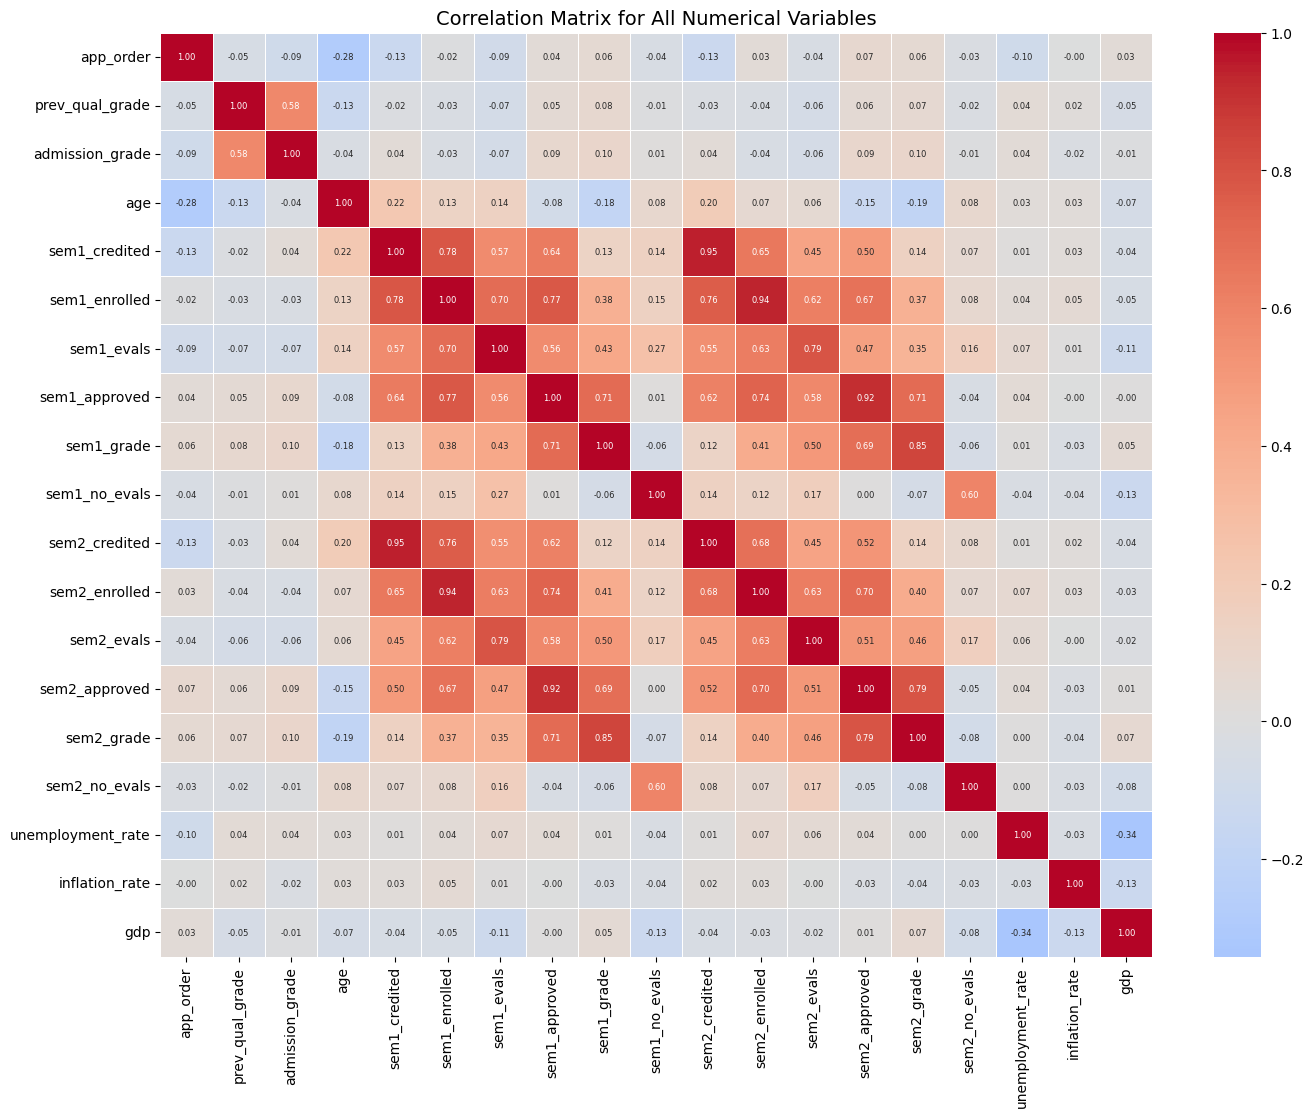

In [91]:
# Correlation Matrix for All Numerical Variables
plt.figure(figsize=(16,12))

corr_matrix = df_model[numerical_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    center=0,
    annot_kws={'fontsize': 6}
)

plt.title("Correlation Matrix for All Numerical Variables", fontsize = 14)
plt.show()

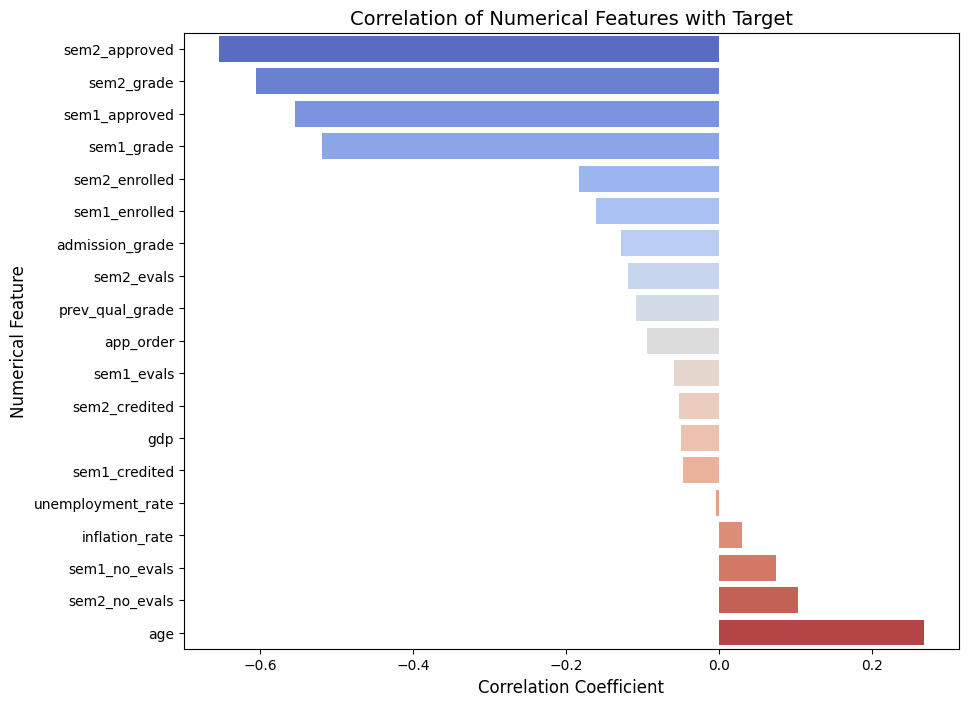

In [87]:
# Correlation of Numerical Features with Target
plt.figure(figsize=(10,8))

# Calculate correlation of all numerical columns with the 'target' column
corr_with_target = df_model[numerical_cols + ['target']].corr()['target']

# Drop the 'target' itself from the series and sort for better visualization
corr_with_target = corr_with_target.drop('target').sort_values(ascending=True)

sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index,
    palette='coolwarm' # Using a diverging palette for correlations
)

plt.title("Correlation of Numerical Features with Target", fontsize = 14)
plt.xlabel("Correlation Coefficient", fontsize = 12)
plt.ylabel("Numerical Feature", fontsize = 12)
plt.show()

In [90]:
corr_with_target

,target
sem2_approved,-0.653995
sem2_grade,-0.605350
sem1_approved,-0.554881
sem1_grade,-0.519927
sem2_enrolled,-0.182897
sem1_enrolled,-0.161074
admission_grade,-0.128058
sem2_evals,-0.119239
prev_qual_grade,-0.109464
app_order,-0.094355


## Top Most Correlated Features with the Target

This is particularly useful for identifying the most impactful features for prediction, regardless of the direction of their influence, as it tells you which features change most predictably with the target.


#Academic Variables
| Feature       | Correlation with Dropout |
| ------------- | -----------------------: |
| sem2_approved |                   -0.654 |
| sem2_grade    |                   -0.605 |
| sem1_approved |                   -0.555 |
| sem1_grade    |                   -0.520 |

# Interpretation
Students who:
- pass more courses,
- obtain higher semester grades,

are substantially less likely to drop out.


# Demographic Variables

| Feature         | Correlation |
| --------------- | ----------: |
| age             |      +0.267 |



#Interpretation

Students who:

- are up-to-date with tuition,
- have scholarships,

are more likely to graduate.

- Students who are debtors are more likely to drop out.

- Older students appear more likely to drop out.

      Possible reasons:

      - Work commitments
      - Family responsibilities
      - Returning to education after a gap


## **Insight (Hypothesis)**:
Academic performance indicators are stronger predictors of student dropout than demographic and socioeconomic characteristics.

**Age at Enrollment**

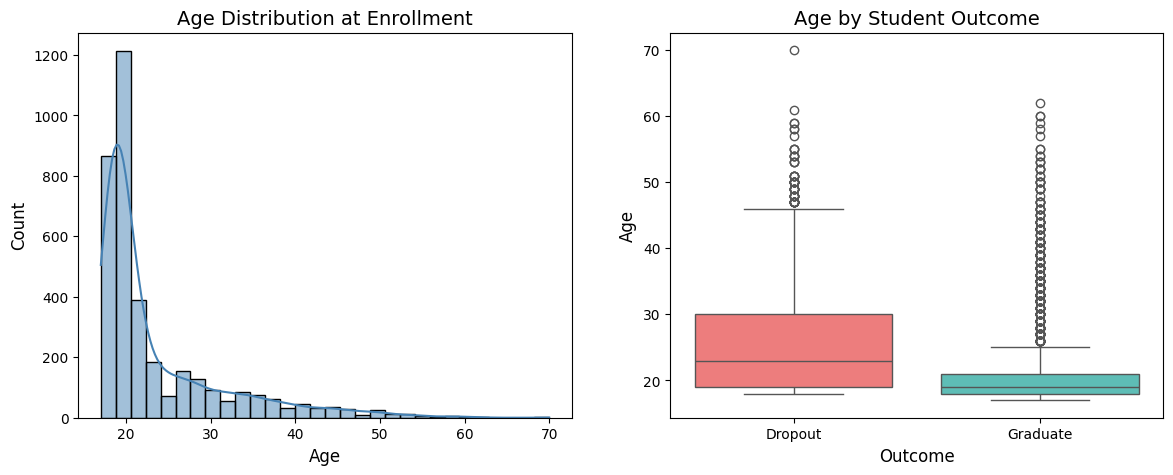

           count       mean       std   min   25%   50%   75%   max
target                                                             
Dropout   1421.0  26.068966  8.704024  18.0  19.0  23.0  30.0  70.0
Graduate  2209.0  21.783612  6.693218  17.0  18.0  19.0  21.0  62.0


In [94]:
# age at the enrollment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#ff6b6b','#4ecdc4',]
# Histogram
sns.histplot(data=df_eda, x='age', bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution at Enrollment', fontsize=14)
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)


# Boxplot by outcome
sns.boxplot(data=df_eda, x='target', y='age', ax=axes[1], palette=colors)
axes[1].set_title('Age by Student Outcome', fontsize=14)
axes[1].set_xlabel('Outcome', fontsize=12)
axes[1].set_ylabel('Age', fontsize=12)

# plt.tight_layout()
plt.show()


print(df_eda.groupby('target')['age'].describe())



Interpretation

While younger students (18-30) dominate the dataset, they also show the highest dropout rates. Older students (30+) are fewer but appear more committed, they rarely drop out



First semester grades

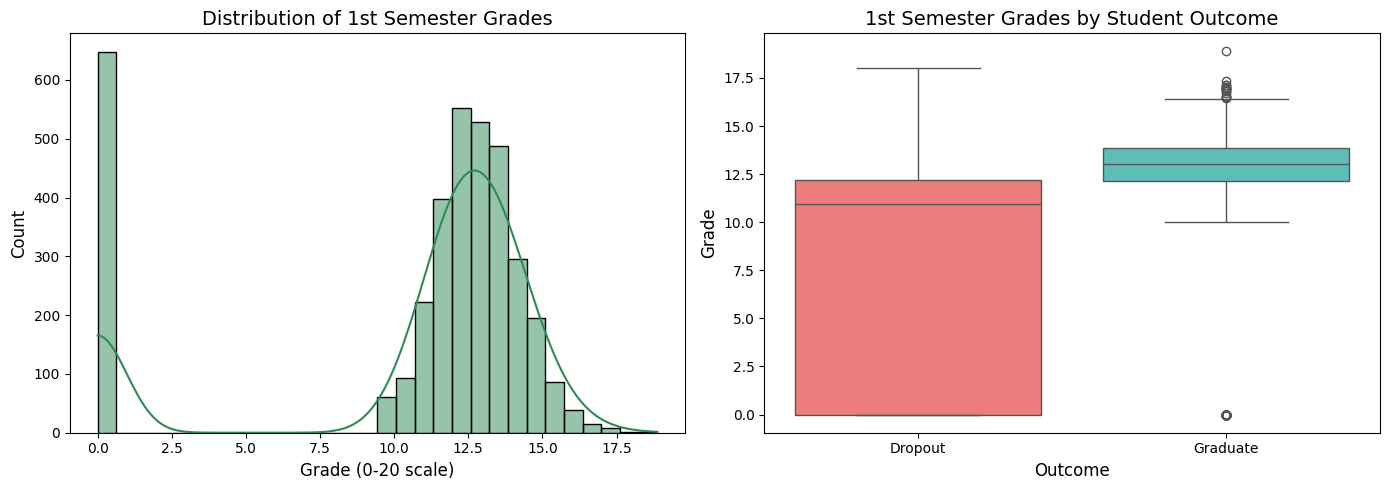

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(data=df_eda, x='sem1_grade', bins=30, kde=True, ax=axes[0], color='seagreen',)
axes[0].set_title('Distribution of 1st Semester Grades', fontsize=14)
axes[0].set_xlabel('Grade (0-20 scale)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Boxplot by outcome
sns.boxplot(data=df_eda, x='target', y='sem1_grade', ax=axes[1], palette=colors,hue='target', legend=False)
axes[1].set_title('1st Semester Grades by Student Outcome', fontsize=14)
axes[1].set_xlabel('Outcome', fontsize=12)
axes[1].set_ylabel('Grade', fontsize=12)

plt.tight_layout()
plt.show()


**Interpretetion of the grph **

# 2.Bivariate Analysis (Two Variables)

1. Students who eventually drop out have a median grade around 10–11, while not graduate have median around 13–14.

2. The distribution is nearly normal (bell-shaped), peaking between 10–14, meaning most students enter university with similar academic ability. However, dropouts show a wider spread with many students scoring below 10,



# Scholarship Status vs Outcome


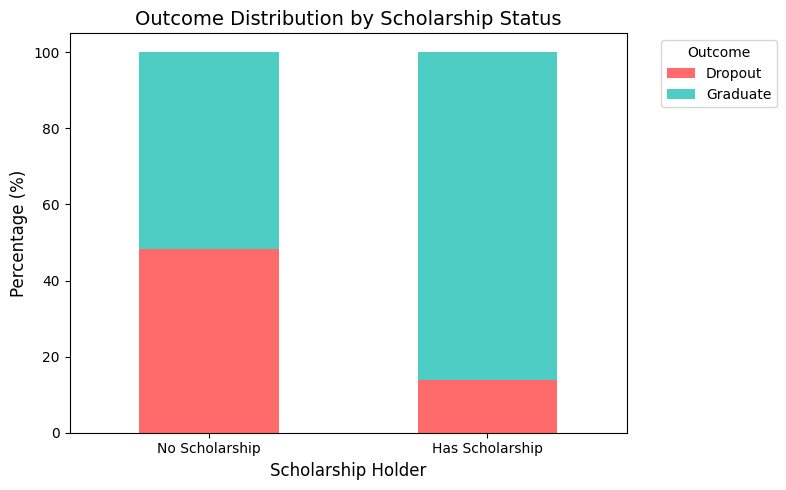

Scholarship vs Outcome (%):
target         Dropout   Graduate
scholarship                      
No           48.365276  51.634724
Yes          13.828689  86.171311


In [28]:
# Cross tabulation with percentages
scholarship_outcome = pd.crosstab(df_eda['scholarship'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
scholarship_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Scholarship Status', fontsize=14)
ax.set_xlabel('Scholarship Holder', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(['No Scholarship', 'Has Scholarship'], rotation=0)
plt.tight_layout()
plt.show()

print("Scholarship vs Outcome (%):")
print(scholarship_outcome)

Interpretetion
1. Scholarship holders have a dramatically lower dropout rate  compared to non-scholarship students. dropout rates is very low around 12% for Scholarship holders whether dropout for non-scholarship is approximatelly 38%.

2. I think This is one of the strongest predictors in the dataset.

3. Expanding scholarship programs may be the single most effective intervention for reducing dropout.Every scholarship dollar appears to have a large impact


# 2 Debtor Status vs Outcome


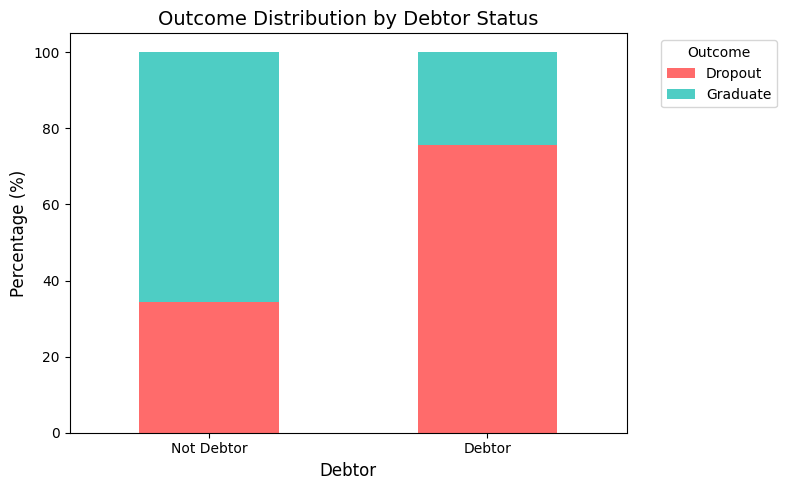

Debtor vs Outcome (%):
target    Dropout   Graduate
Debtor                      
No      34.473112  65.526888
Yes     75.544794  24.455206


In [29]:
debtor_outcome = pd.crosstab(
    df_eda['Debtor'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
debtor_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Debtor Status', fontsize=14)
ax.set_xlabel('Debtor', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(['Not Debtor', 'Debtor'], rotation=0)
plt.tight_layout()
plt.show()

print("Debtor vs Outcome (%):")
print(debtor_outcome)

**Interpretation **
1. Debtors have a significantly higher dropout rate  compared to non-debtors

2. I can say Financial stress appears directly linked to leaving school.

3. Financial counseling and emergency aid programs should target identified debtors early. Even small financial interventions might prevent dropout for this group.

# 3. Marital Status vs Outcome


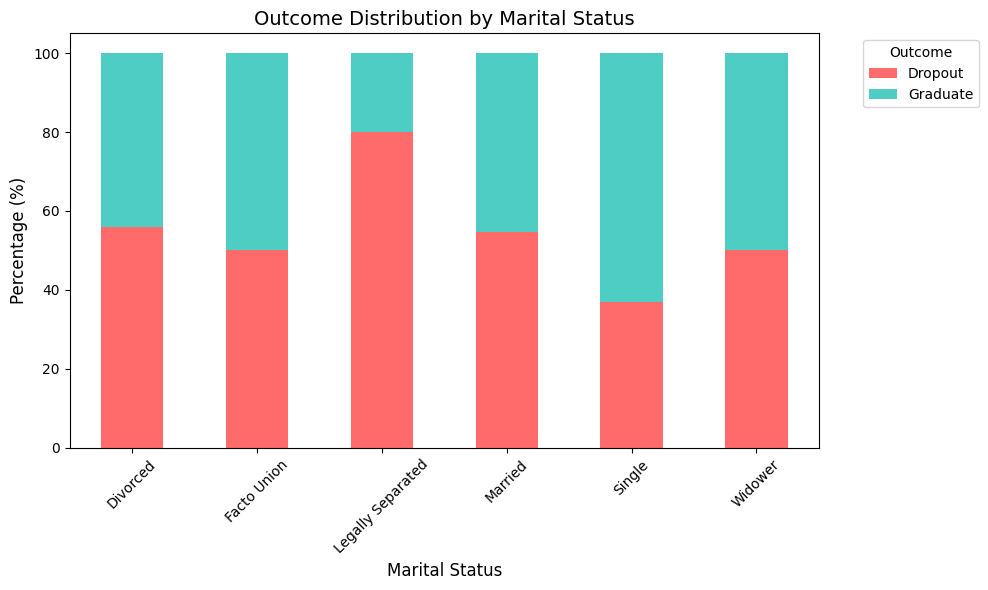

Marital Status vs Outcome (%):
target               Dropout   Graduate
marital_status                         
Divorced           56.000000  44.000000
Facto Union        50.000000  50.000000
Legally Separated  80.000000  20.000000
Married            54.740061  45.259939
Single             37.011566  62.988434
Widower            50.000000  50.000000


In [30]:
marital_outcome = pd.crosstab(df_eda['marital_status'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff6b6b','#4ecdc4',]
marital_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Marital Status', fontsize=14)
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Marital Status vs Outcome (%):")
print(marital_outcome)

Interpretation

1. Legally separated students tends to dropout more compared to another marital status

2.  single students show the lowest dropout.

3. the widower students tend to not dropout compared to another marital status

# Outcome analysis by Attendance



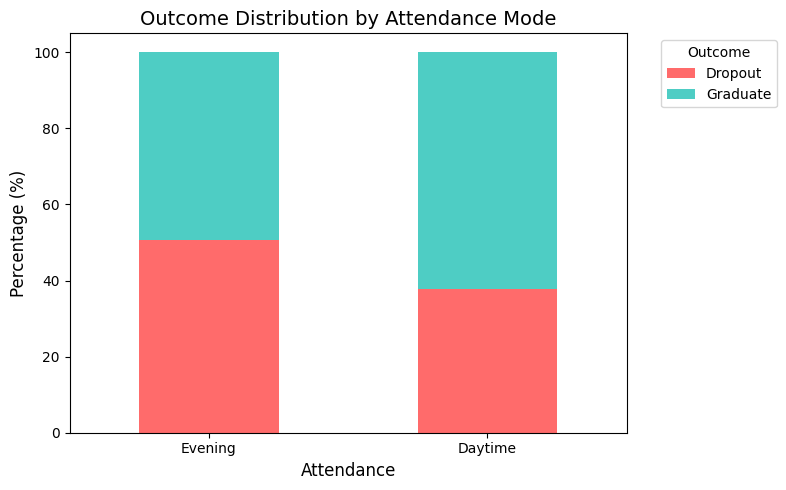

Attendance vs Outcome (%):
target                Dropout   Graduate
daytime_attendance                      
No                  50.735294  49.264706
Yes                 37.678461  62.321539


In [31]:
attendance_outcome = pd.crosstab(df_eda['daytime_attendance'], df_eda['target'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#ff6b6b','#4ecdc4',]
attendance_outcome.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Outcome Distribution by Attendance Mode', fontsize=14)
ax.set_xlabel('Attendance', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels(['Evening', 'Daytime'], rotation=0)
plt.tight_layout()
plt.show()

print("Attendance vs Outcome (%):")
print(attendance_outcome)

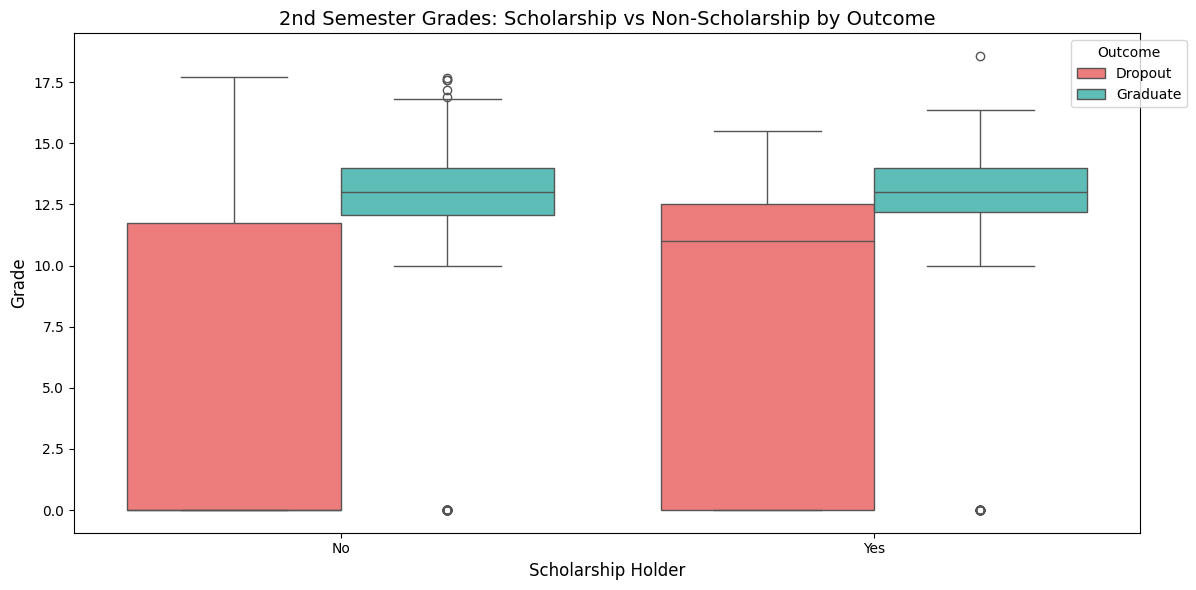

In [32]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_eda, x='scholarship', y='sem2_grade', hue='target', palette=colors)
plt.title('2nd Semester Grades: Scholarship vs Non-Scholarship by Outcome', fontsize=14)
plt.xlabel('Scholarship Holder', fontsize=12)
plt.ylabel('Grade', fontsize=12)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Interpretation**

1. scholarship holders who drop out have grades nearly as low as non-scholarship dropouts which  means scholarship alone doesn't save a student with very poor performance.

# Analysis of outcome by age and grades


===========================================

In [204]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

In [33]:
# Import other libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
np.random.seed(42)


# **4. Train/Test Split & Baseline Models**

In [96]:
df_model

,marital_status,app_mode,app_order,Course,daytime_attendance,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_credited,sem2_enrolled,sem2_evals,sem2_approved,sem2_grade,sem2_no_evals,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,0
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,1
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,1
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,0


4.2. Feature-Target Split


In [97]:

# Features and target
X = df_model.drop("target", axis=1)
y = df_model["target"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (3630, 36)
Target Shape: (3630,)


4.3 Train/Split data

In [98]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (2904, 36)
Testing Set : (726, 36)


In [99]:
# Verify Class Distribution
print("Overall:")
print(y.value_counts(normalize=True))

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Overall:
target
0    0.60854
1    0.39146
Name: proportion, dtype: float64

Train:
target
0    0.608471
1    0.391529
Name: proportion, dtype: float64

Test:
target
0    0.608815
1    0.391185
Name: proportion, dtype: float64


**4.4 Statistical Baseline: Dummy Classifier**

It is used as a baseline to determine whether more sophisticated models are actually adding predictive value. Can we beat a model that does not learn anything?

In [100]:
baseline_dummy = DummyClassifier(strategy='most_frequent')

baseline_dummy.fit(X_train, y_train)

baseline_dummy_pred = baseline_dummy.predict(X_test)

# Create a proper metrics dictionary (same structure as evaluate_model output)
baseline_dummy_scores = {
    "Accuracy": accuracy_score(y_test, baseline_dummy_pred),
    "Precision": precision_score(y_test, baseline_dummy_pred),
    "Recall": recall_score(y_test, baseline_dummy_pred),
    "F1": f1_score(y_test, baseline_dummy_pred),
    "ROC_AUC": roc_auc_score(y_test, baseline_dummy_pred),
    "Model": "DummyClassifier",
    "Experiment": "Baseline_Dummy"
}

# Convert it into DataFrame
results_baseline_dummy = pd.DataFrame([baseline_dummy_scores])
results_baseline_dummy

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.608815,0.0,0.0,0.0,0.5,DummyClassifier,Baseline_Dummy


4.5 Preprocessing Pipeline

In [101]:

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_cols)
    ])

### Applying Preprocessing for Scaled Data

Before applying RFE and PCA, we need to transform our `X_train` and `X_test` datasets using the defined `preprocessor`. This step scales numerical features and one-hot encodes categorical features, creating `X_train_scaled` and `X_test_scaled`.

In [139]:
# Apply the preprocessor to X_train and X_test
X_train_scaled = preprocessor.fit_transform(X_train, y_train)
X_test_scaled = preprocessor.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (2904, 235)
Shape of X_test_scaled: (726, 235)


With `X_train_scaled` and `X_test_scaled` now available, the RFE and PCA steps will execute without the `NameError`.

**4.6. ML Baseline: Logistic Regression**

This is our first real machine learning model.

In [115]:
# Create full pipeline with Logistic Regression
log_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


# Train the model
log_reg_model.fit(X_train, y_train)

# predict the model
baseline_lr_pred = log_reg_model.predict(X_test)

# Create a proper metrics dictionary (same structure as evaluate_model output)
log_reg_model_score= {
    "Accuracy": accuracy_score(y_test,baseline_lr_pred ),
    "Precision": precision_score(y_test, baseline_lr_pred ),
    "Recall": recall_score(y_test, baseline_lr_pred ),
    "F1": f1_score(y_test, baseline_lr_pred ),
    "ROC_AUC": roc_auc_score(y_test, baseline_lr_pred ),
    "Model": "Logistic regression",
    "Experiment": "Baseline_LogisticRegression"
}

# Convert it into DataFrame
results_baseline_regression = pd.DataFrame([log_reg_model_score])
results_baseline_regression


,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.933884,0.909722,0.922535,0.916084,0.931856,Logistic regression,Baseline_LogisticRegression


In [111]:
X_train.shape
X_test.shape

(726, 36)

4.7 Confusion matrix for Baseline logistic regression

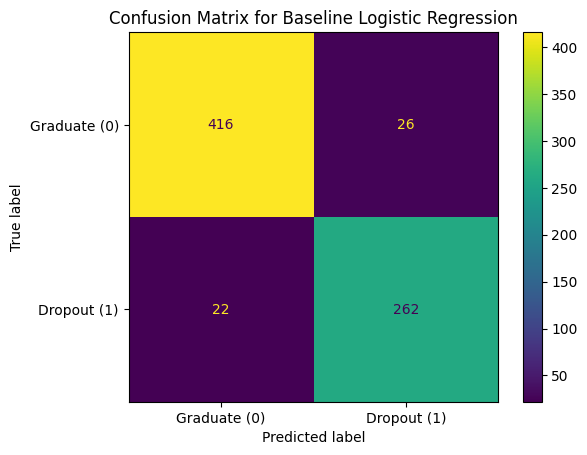

In [113]:
# Compute confusion matrix for baseline_lr
cm_baseline_lr = confusion_matrix(
    y_test,
    baseline_lr_pred
)

# Display confusion matrix visually
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline_lr,
    display_labels=['Graduate (0)', 'Dropout (1)']
).plot()

plt.title('Confusion Matrix for Baseline Logistic Regression')
plt.show()

**4.8. Dummy model and baseline logistic regression comparison**

In [116]:
baseline_results = pd.DataFrame({
    "DummyClassifier": baseline_dummy_scores,
    "Logistic Regression": log_reg_model_score
})

baseline_results.T

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
DummyClassifier,0.608815,0.0,0.0,0.0,0.5,DummyClassifier,Baseline_Dummy
Logistic Regression,0.933884,0.909722,0.922535,0.916084,0.931856,Logistic regression,Baseline_LogisticRegression


# Interpretation:
A simple Log Reg using all features is already achieving high accuracy.

`Now, Can we achieve similar performance using fewer features?`



# **5. Feature Selection**

**To test the following hypothesis:**

H₀: Feature selection does not improve performance.

H₁: Feature selection can maintain or improve performance while reducing dimensionality.

1. Filter Method (SelectBest using F-Score)

In [229]:
lr_kbest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=15)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_kbest.fit(X_train, y_train)

y_pred = lr_kbest.predict(X_test)
y_prob = lr_kbest.predict_proba(X_test)[:, 1]


kbest_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "LR + Filter Method",
    "Experiment": "SelectKBest"
}

kbest_results = pd.DataFrame([kbest_results])
kbest_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.899449,0.889299,0.848592,0.868468,0.942901,LR + Filter Method,SelectKBest


In [235]:
selected_features_indices = lr_kbest.named_steps['feature_selection'].get_support(indices=True)
all_features = lr_kbest.named_steps['preprocessor'].get_feature_names_out()
kbest_selected_features = all_features[selected_features_indices]
print("Features selected by SelectKBest:")
print(kbest_selected_features)
print(f"\nNumber of features selected by SelectKBest: {len(kbest_selected_features)}\n")

Features selected by SelectKBest:
['num__age' 'num__sem1_approved' 'num__sem1_grade' 'num__sem2_approved'
 'num__sem2_grade' 'cat__app_mode_1' 'cat__app_mode_39' 'cat__Debtor_0'
 'cat__Debtor_1' 'cat__tuition_current_0' 'cat__tuition_current_1'
 'cat__Gender_0' 'cat__Gender_1' 'cat__scholarship_0' 'cat__scholarship_1']

Number of features selected by SelectKBest: 15



In [234]:
cleaned_kbest_features_temp = []
for col in kbest_selected_features:
    # Remove 'num__' or 'cat__' prefixes
    clean_col = col.replace('num__', '').replace('cat__', '')

    # Check if the feature is a numerical one that might have underscores (e.g., sem1_grade)
    # If it's not a known numerical feature, and it contains an underscore,
    # assume it's a one-hot encoded categorical feature and take the part before the first underscore.
    if clean_col not in numerical_cols and '_' in clean_col:
        cleaned_kbest_features_temp.append(clean_col.split('_', 1)[0])
    else:
        cleaned_kbest_features_temp.append(clean_col)

# Get unique features and sort them
cleaned_kbest_features = sorted(list(set(cleaned_kbest_features_temp)))

print("Original features selected by SelectKBest:")
print(cleaned_kbest_features)
print(f"\nNumber of original features selected by SelectKBest: {len(cleaned_kbest_features)}\n")

Original features selected by SelectKBest:
['Debtor', 'Gender', 'age', 'app', 'scholarship', 'sem1_approved', 'sem1_grade', 'sem2_approved', 'sem2_grade', 'tuition']

Number of original features selected by SelectKBest: 10



2. Wrapper Method (RFE)

In [256]:
rfe_estimator = LogisticRegression(max_iter=1000, random_state=42)

lr_rfe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', RFE(
        estimator=rfe_estimator,
        n_features_to_select=14,
        step=0.1
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_rfe.fit(X_train, y_train)

y_pred = lr_rfe.predict(X_test)
y_prob = lr_rfe.predict_proba(X_test)[:, 1]


rfe_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "LR + RFE",
    "Experiment": "RFE"
}

rfe_results = pd.DataFrame([rfe_results])
rfe_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.938017,0.944238,0.894366,0.918626,0.968509,LR + RFE,RFE


In [257]:
selected_features_rfe_indices = lr_rfe.named_steps['feature_selection'].get_support(indices=True)
all_features_preprocessed = lr_rfe.named_steps['preprocessor'].get_feature_names_out()
rfe_selected_features = all_features_preprocessed[selected_features_rfe_indices]

cleaned_rfe_features_temp = []
for col in rfe_selected_features:
    # Remove 'num__' or 'cat__' prefixes
    clean_col = col.replace('num__', '').replace('cat__', '')

    # If it's a categorical feature (indicated by _ and not a numerical column name),
    # take the part before the first underscore (e.g., 'app_mode_1' -> 'app_mode').
    # Otherwise, keep the cleaned column name.
    if clean_col not in numerical_cols and '_' in clean_col and clean_col.split('_')[0] in categorical_cols:
        cleaned_rfe_features_temp.append(clean_col.split('_')[0])
    else:
        cleaned_rfe_features_temp.append(clean_col)

# Get unique features and sort them
cleaned_rfe_features = sorted(list(set(cleaned_rfe_features_temp)))

print("Features selected by RFE:")
for feature in cleaned_rfe_features:
    print(f"- {feature}")
print(f"\nNumber of features selected by RFE: {len(cleaned_rfe_features)}")

Features selected by RFE:
- Course
- Debtor
- father_occ_0
- nationality
- prev_qual_4
- prev_qual_42
- sem1_approved
- sem1_enrolled
- sem2_approved
- sem2_enrolled
- tuition_current_0
- tuition_current_1

Number of features selected by RFE: 12


In [258]:
selected_features_rfe_indices = lr_rfe.named_steps['feature_selection'].get_support(indices=True)
all_features_preprocessed = lr_rfe.named_steps['preprocessor'].get_feature_names_out()
rfe_selected_features = all_features_preprocessed[selected_features_rfe_indices]

cleaned_rfe_features_temp = []
for col in rfe_selected_features:
    # Remove 'num__' or 'cat__' prefixes
    clean_col = col.replace('num__', '').replace('cat__', '')

    is_grouped = False
    for cat_feature_name in categorical_cols:
        # Check if the cleaned column starts with a categorical feature name and contains an underscore
        # This handles cases like 'app_mode_1' -> 'app_mode' and also 'prev_qual_4' -> 'prev_qual'
        if clean_col.startswith(cat_feature_name) and '_' in clean_col and clean_col != cat_feature_name:
            cleaned_rfe_features_temp.append(cat_feature_name)
            is_grouped = True
            break # Found a match, no need to check other categorical_cols

    if not is_grouped:
        # If it wasn't grouped by a categorical feature (e.g., it's a numerical feature or not OHE)
        cleaned_rfe_features_temp.append(clean_col)

# Get unique features and sort them
cleaned_rfe_features = sorted(list(set(cleaned_rfe_features_temp)))

print("Features selected by RFE:")
for feature in cleaned_rfe_features:
    print(f"- {feature}")
print(f"\nNumber of features selected by RFE: {len(cleaned_rfe_features)}")

Features selected by RFE:
- Course
- Debtor
- father_occ
- nationality
- prev_qual
- sem1_approved
- sem1_enrolled
- sem2_approved
- sem2_enrolled
- tuition_current

Number of features selected by RFE: 10


3. Embedded Method

In [259]:
embedded_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='saga',      # required for L1
        max_iter=2000,
        random_state=42
    ))
])

embedded_lr.fit(X_train, y_train)

y_pred = embedded_lr.predict(X_test)
y_prob = embedded_lr.predict_proba(X_test)[:, 1]

embedded_lr_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "LR + Embedded",
    "Experiment": "Embedded"
}

embedded_lr_results = pd.DataFrame([embedded_lr_results])
embedded_lr_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.933884,0.909722,0.922535,0.916084,0.976635,LR + Embedded,Embedded


In [270]:
# User can adjust C_param_for_l1 to control the number of selected features (sparsity).
# Smaller C values lead to stronger regularization and fewer selected features.
# The default C is 1.0. Adjusting this value will change the number of selected features.
C_param_for_l1 = 0.02

embedded_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='saga',      # required for L1
        max_iter=2000,
        random_state=42,
        C=C_param_for_l1 # Use the adjustable C parameter
    ))
])

embedded_lr.fit(X_train, y_train)

y_pred = embedded_lr.predict(X_test)
y_prob = embedded_lr.predict_proba(X_test)[:, 1]

embedded_lr_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "LR + Embedded",
    "Experiment": "Embedded"
}

embedded_lr_results = pd.DataFrame([embedded_lr_results])
embedded_lr_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.904959,0.893773,0.859155,0.876122,0.959563,LR + Embedded,Embedded


In [271]:
classifier_model = embedded_lr.named_steps['classifier']
coefficients = classifier_model.coef_[0]

# Get feature names after preprocessing
preprocessor_feature_names = embedded_lr.named_steps['preprocessor'].get_feature_names_out()

# Identify selected features (non-zero coefficients)
selected_features_indices = np.where(coefficients != 0)[0]
selected_features_count = len(selected_features_indices)
selected_feature_names = preprocessor_feature_names[selected_features_indices]

print(f"Number of features selected by LR + Embedded: {selected_features_count}")
print("Selected features:")
for feature in selected_feature_names:
    print(f"- {feature}")

Number of features selected by LR + Embedded: 12
Selected features:
- num__admission_grade
- num__age
- num__sem1_evals
- num__sem1_approved
- num__sem2_credited
- num__sem2_enrolled
- num__sem2_approved
- num__sem2_grade
- cat__tuition_current_0
- cat__tuition_current_1
- cat__scholarship_0
- cat__scholarship_1


In [272]:
cleaned_embedded_features_temp = []
for col in selected_feature_names:
    if col.startswith('num__'):
        # It's a numerical feature, remove prefix and add
        cleaned_embedded_features_temp.append(col.replace('num__', ''))
    elif col.startswith('cat__'):
        # It's a categorical feature, remove prefix and get the base name
        clean_cat_col = col.replace('cat__', '')
        cleaned_embedded_features_temp.append(clean_cat_col.split('_')[0])

# Get unique features and sort them
original_embedded_features = sorted(list(set(cleaned_embedded_features_temp)))

print("Original features selected by LR + Embedded:")
for feature in original_embedded_features:
    print(f"- {feature}")
print(f"\nNumber of features selected by LR + Embedded: {len(original_embedded_features)}")

Original features selected by LR + Embedded:
- admission_grade
- age
- scholarship
- sem1_approved
- sem1_evals
- sem2_approved
- sem2_credited
- sem2_enrolled
- sem2_grade
- tuition

Number of features selected by LR + Embedded: 10


## PCA: Principal Component Analysis

In [279]:
lr_pca = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.67)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pca.fit(X_train, y_train)

y_pred = lr_pca.predict(X_test)
y_prob = lr_pca.predict_proba(X_test)[:, 1]

pca_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Model": "LR + OHE + PCA",
    "Experiment": "PCA"
}

pca_results = pd.DataFrame([pca_results])
pca_results

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.876033,0.836806,0.848592,0.842657,0.939121,LR + OHE + PCA,PCA


Number of components retained by PCA: 10




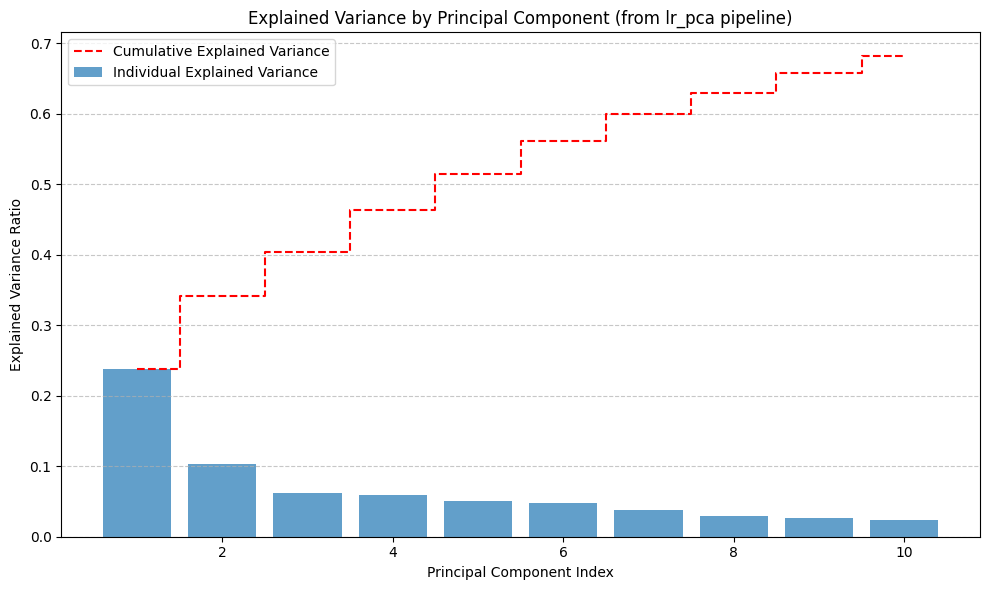

In [280]:
pca_model = lr_pca.named_steps['pca']
n_components = pca_model.n_components_
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Number of components retained by PCA: {n_components}\n\n")

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, label='Individual Explained Variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative Explained Variance', linestyle='--', color='red')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component (from lr_pca pipeline)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Model** **comparison**

In [281]:
# Combine the results from all experiments into one DataFrame
comparison = pd.concat([
    results_baseline_dummy,  # Baseline (DummyClassifier)
    results_baseline_regression,    # Experiment 1: All Features (Logistic Regression)
    kbest_results,     # Experiment 2: Mutual Information Feature Selection (Logistic Regression + SelectKBest)
    rfe_results,    # Experiment 3: Recursive Feature Elimination (RFE) (Logistic Regression + RFE)
    embedded_lr_results, # Adding embedded results
    pca_results     # Experiment 4: Principal Component Analysis (PCA) (Logistic Regression + PCA)
], ignore_index=True)

# Display the combined results
display(comparison)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
0,0.608815,0.000000,0.000000,0.000000,0.500000,DummyClassifier,Baseline_Dummy
1,0.933884,0.909722,0.922535,0.916084,0.931856,Logistic regression,Baseline_LogisticRegression
2,0.899449,0.889299,0.848592,0.868468,0.942901,LR + Filter Method,SelectKBest
3,0.938017,0.944238,0.894366,0.918626,0.968509,LR + RFE,RFE
4,0.904959,0.893773,0.859155,0.876122,0.959563,LR + Embedded,Embedded
5,0.876033,0.836806,0.848592,0.842657,0.939121,LR + OHE + PCA,PCA


In [282]:
comparison.sort_values(
    by='F1',   # balance between precision & recall - Balanced classification
    ascending=False
).head()

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
3,0.938017,0.944238,0.894366,0.918626,0.968509,LR + RFE,RFE
1,0.933884,0.909722,0.922535,0.916084,0.931856,Logistic regression,Baseline_LogisticRegression
4,0.904959,0.893773,0.859155,0.876122,0.959563,LR + Embedded,Embedded
2,0.899449,0.889299,0.848592,0.868468,0.942901,LR + Filter Method,SelectKBest
5,0.876033,0.836806,0.848592,0.842657,0.939121,LR + OHE + PCA,PCA


In [283]:
comparison.sort_values(by='ROC_AUC', ascending=False).head() # ranking ability

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
3,0.938017,0.944238,0.894366,0.918626,0.968509,LR + RFE,RFE
4,0.904959,0.893773,0.859155,0.876122,0.959563,LR + Embedded,Embedded
2,0.899449,0.889299,0.848592,0.868468,0.942901,LR + Filter Method,SelectKBest
5,0.876033,0.836806,0.848592,0.842657,0.939121,LR + OHE + PCA,PCA
1,0.933884,0.909722,0.922535,0.916084,0.931856,Logistic regression,Baseline_LogisticRegression


In [284]:
comparison.sort_values(by='Accuracy', ascending=False).head()

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
3,0.938017,0.944238,0.894366,0.918626,0.968509,LR + RFE,RFE
1,0.933884,0.909722,0.922535,0.916084,0.931856,Logistic regression,Baseline_LogisticRegression
4,0.904959,0.893773,0.859155,0.876122,0.959563,LR + Embedded,Embedded
2,0.899449,0.889299,0.848592,0.868468,0.942901,LR + Filter Method,SelectKBest
5,0.876033,0.836806,0.848592,0.842657,0.939121,LR + OHE + PCA,PCA


In [285]:
comparison.sort_values(by='Precision', ascending=False).head()

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
3,0.938017,0.944238,0.894366,0.918626,0.968509,LR + RFE,RFE
1,0.933884,0.909722,0.922535,0.916084,0.931856,Logistic regression,Baseline_LogisticRegression
4,0.904959,0.893773,0.859155,0.876122,0.959563,LR + Embedded,Embedded
2,0.899449,0.889299,0.848592,0.868468,0.942901,LR + Filter Method,SelectKBest
5,0.876033,0.836806,0.848592,0.842657,0.939121,LR + OHE + PCA,PCA


In [286]:
comparison.sort_values(by='Recall', ascending=False).head()

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Experiment
1,0.933884,0.909722,0.922535,0.916084,0.931856,Logistic regression,Baseline_LogisticRegression
3,0.938017,0.944238,0.894366,0.918626,0.968509,LR + RFE,RFE
4,0.904959,0.893773,0.859155,0.876122,0.959563,LR + Embedded,Embedded
2,0.899449,0.889299,0.848592,0.868468,0.942901,LR + Filter Method,SelectKBest
5,0.876033,0.836806,0.848592,0.842657,0.939121,LR + OHE + PCA,PCA


## **Tuning the best model based on F1**

In [ ]:
print("\nFull Model Comparison (Sorted by ROC_AUC Score):\n")
print(full_comparison.sort_values(by='ROC_AUC', ascending=False))



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'Baseline' and 'Tuned' experiments for this comparison
comparison_filtered = full_comparison[~full_comparison['Experiment'].isin(['Baseline', 'Tuned'])].copy()

# Map Model names for cleaner display on the plot
model_name_map = {
    'Logistic Regression': 'LogReg',
    'Decision Tree': 'DT',
    'Random Forest': 'RF',
    'XGBoost': 'XGBoost'
}
comparison_filtered['Model'] = comparison_filtered['Model'].map(model_name_map)

# Map Experiment names for cleaner display on the plot and consistent ordering
experiment_order = {
    'All Features': 'All Features',
    'Principal Component Analysis (PCA)': 'PCA',
    'Mutual Information': 'MI',
    'Recursive Feature Elimination (RFE)': 'RFE'
}
comparison_filtered['Experiment'] = comparison_filtered['Experiment'].map(experiment_order)

# Ensure the order of experiments in the plot
comparison_filtered['Experiment'] = pd.Categorical(
    comparison_filtered['Experiment'],
    categories=['All Features', 'PCA', 'MI', 'RFE'],
    ordered=True
)

plt.figure(figsize=(14, 8)) # Increased figure size for better readability of labels
ax = sns.barplot(
    data=comparison_filtered,
    x='Model',
    y='F1',
    hue='Experiment',
    palette='Blues' # Changed color palette to 'Blues'
)

# Add percentage of F1 score at the top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()*100:.1f}%', # Format as percentage with one decimal place
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 10), textcoords='offset points',
        fontsize=8, color='black' # Smaller font and black color for better readability
    )

plt.title('F1-Score Comparison Across Models and Dimensionality Reduction Techniques', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(title='Feature Selection Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for tuned models only
tuned_models_comparison = full_comparison[full_comparison['Experiment'] == 'Tuned'].copy()

# Sort by F1 score for better visualization
tuned_models_comparison = tuned_models_comparison.sort_values(by='F1', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=tuned_models_comparison,
    x='Model',
    y='F1',
    palette='viridis' # Choose a color palette
)

# Add percentage of F1 score at the top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()*100:.2f}%', # Format as percentage with two decimal places
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 10), textcoords='offset points',
        fontsize=10, color='black'
    )

plt.title('F1-Score Comparison for Tuned Models', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'Baseline' and 'Tuned' experiments for this comparison
comparison_filtered = full_comparison[~full_comparison['Experiment'].isin(['Baseline', 'Tuned'])].copy()

# Map Model names for cleaner display on the plot
model_name_map = {
    'Logistic Regression': 'LogReg',
    'Decision Tree': 'DT',
    'Random Forest': 'RF',
    'XGBoost': 'XGBoost'
}
comparison_filtered['Model'] = comparison_filtered['Model'].map(model_name_map)

# Map Experiment names for cleaner display on the plot and consistent ordering
experiment_order = {
    'All Features': 'All Features',
    'Principal Component Analysis (PCA)': 'PCA',
    'Mutual Information': 'MI',
    'Recursive Feature Elimination (RFE)': 'RFE'
}
comparison_filtered['Experiment'] = comparison_filtered['Experiment'].map(experiment_order)

# Ensure the order of experiments in the plot
comparison_filtered['Experiment'] = pd.Categorical(
    comparison_filtered['Experiment'],
    categories=['All Features', 'PCA', 'MI', 'RFE'],
    ordered=True
)

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=comparison_filtered,
    x='Model',
    y='ROC_AUC',
    hue='Experiment',
    palette='Blues' # Changed color palette to 'Blues'
)

# Add percentage of ROC_AUC score at the top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()*100:.1f}%', # Format as percentage with one decimal place
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 10), textcoords='offset points',
        fontsize=8, color='black' # Smaller font and black color for better readability
    )

plt.title('ROC-AUC Score Comparison Across Models and Dimensionality Reduction Techniques', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.legend(title='Feature Selection Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Confusion Matrix**

In [ ]:
# Get the best model from GridSearchCV
best_log_reg_model = grid.best_estimator_

# Make predictions on the test set
pred = best_log_reg_model.predict(
    X_test_scaled
)

# Compute confusion matrix
cm = confusion_matrix(
    y_test,
    pred
)

# Display confusion matrix visually
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['NotDropout (0)', 'Dropout (1)']
).plot()

# Show the plot
plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

## **Feature Importance**

In [ ]:
# Sort and take top 15 features
top_features = importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    top_features['Feature'][::-1],      # reverse for descending order
    top_features['Importance'][::-1]
)

# Labels and title
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.show()

=====================================
